# Install/import libraries

In [44]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

# Unzip the dataset

In [45]:
zip_path = "/content/drive/MyDrive/AI-ML/Data/week5/FruitinAmazon.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Corrected base_dir to point to the extracted content
base_dir = "/content/FruitinAmazon"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)

Train path: /content/FruitinAmazon/train
Test path: /content/FruitinAmazon/test


# Task 1: Data understanding and visualization

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


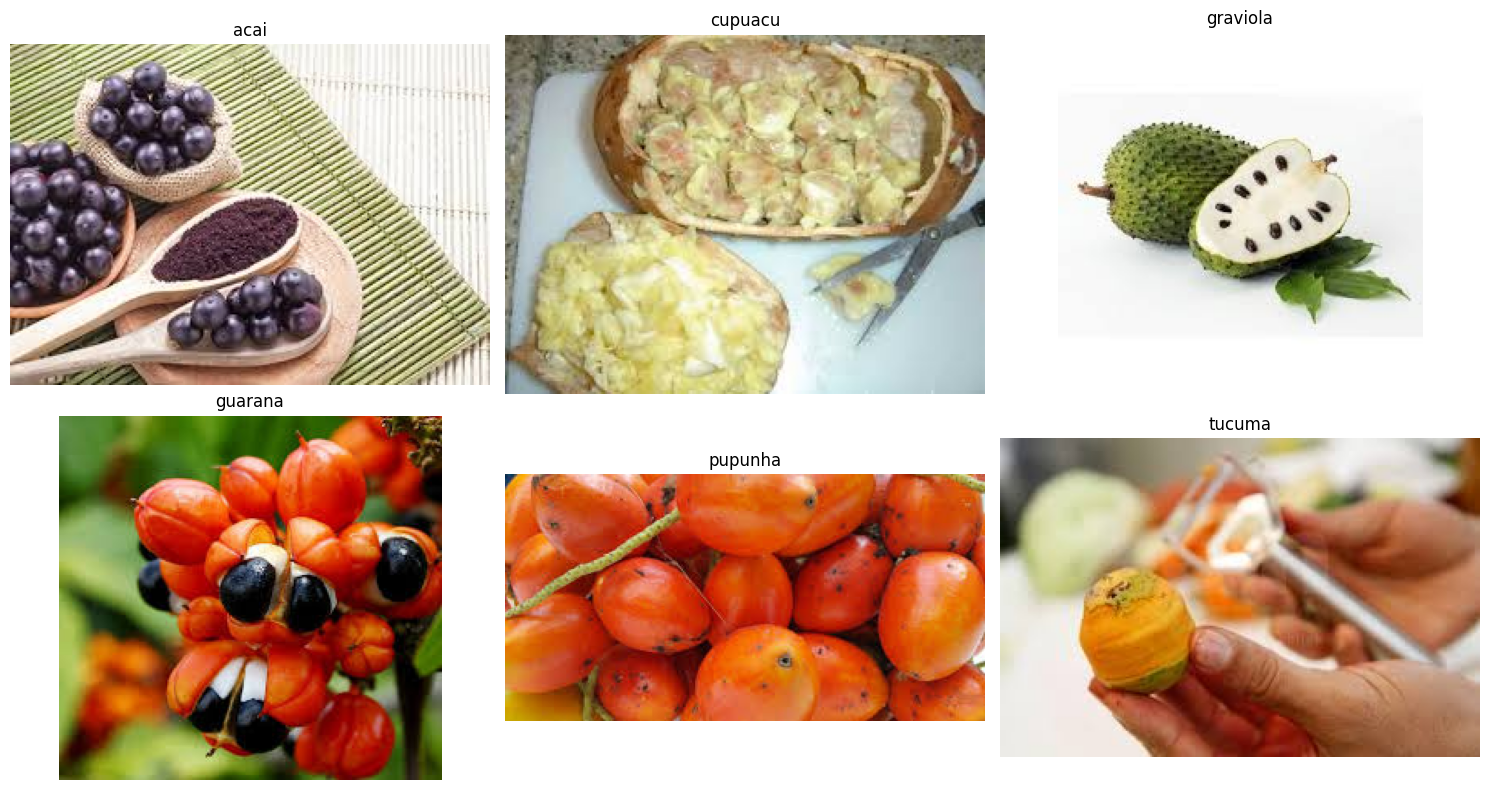

In [46]:
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", class_names)

sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    chosen = random.choice(images)
    sample_images.append((class_name, os.path.join(class_path, chosen)))

plt.figure(figsize=(15, 8))

for i, (class_name, img_path) in enumerate(sample_images):
    plt.subplot(2, 3, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 1: Check corrupted images

In [47]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError, OSError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


# Task 2: Load and preprocess image data

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.

--- Verifying raw dataset batch before rescaling ---
  Image batch shape: (16, 128, 128, 3)
  Label batch shape: (16,)
  Image data type: <dtype: 'float32'>
  Image pixel value range (example first image): 0.0579071044921875 - 255.0
  First 5 labels in batch: [1 0 5 4 4]


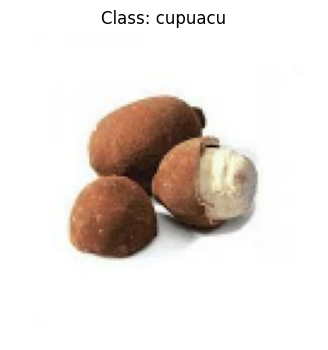

--- End raw dataset verification ---

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [48]:
img_height = 128
img_width = 128
batch_size = 16   # use 16 because training requirement later says batch size 16
validation_split = 0.2
seed = 123

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names

# --- Verification before mapping ---
print("\n--- Verifying raw dataset batch before rescaling ---")
for image_batch, labels_batch in train_ds.take(1):
    print(f"  Image batch shape: {image_batch.shape}")
    print(f"  Label batch shape: {labels_batch.shape}")
    print(f"  Image data type: {image_batch.dtype}")
    print(f"  Image pixel value range (example first image): {image_batch[0].numpy().min()} - {image_batch[0].numpy().max()}")
    print(f"  First 5 labels in batch: {labels_batch.numpy()[:5]}")

    # Display one image to verify (should be 0-255)
    plt.figure(figsize=(4, 4))
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(f"Class: {class_names[labels_batch[0].numpy()]}")
    plt.axis("off")
    plt.show()
print("--- End raw dataset verification ---\n")
# --- End Verification before mapping ---

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

In [49]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Task 3: Build the CNN model

In [50]:
model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the model

In [51]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train the model

In [52]:
checkpoint = ModelCheckpoint(
    "best_fruit_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.1632 - loss: 1.9018
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 383ms/step - accuracy: 0.1806 - loss: 1.8964 - val_accuracy: 0.8333 - val_loss: 1.5511
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.3389 - loss: 1.7014
Epoch 2: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - accuracy: 0.3611 - loss: 1.6857 - val_accuracy: 0.1667 - val_loss: 1.8875
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.4788 - loss: 1.4843
Epoch 3: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.4722 - loss: 1.4482 - val_accuracy: 0.5556 - val_loss: 1.3729
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.7035 - loss: 1.0529
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 0.6944 - loss: 1.0568 - val_accuracy: 0.5556 - val_loss: 1.2941
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8135 - loss:


Epoch 5: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 314ms/step - accuracy: 0.7917 - loss: 0.6707 - val_accuracy: 0.8889 - val_loss: 0.5579
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.8410 - loss: 0.4062
Epoch 6: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 508ms/step - accuracy: 0.8611 - loss: 0.3942 - val_accuracy: 0.7778 - val_loss: 0.8645
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.9712 - loss: 0.2213
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 487ms/step - accuracy: 0.9861 - loss: 0.1896 - val_accuracy: 0.8889 - val_loss: 0.3346
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9451 - loss: 0.1152
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 295ms/step - accuracy: 0.9444 - loss: 0.1149 - val_accuracy: 0.8889 - val_loss: 0.3663
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9712 - loss:


Epoch 10: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - accuracy: 0.9583 - loss: 0.0861 - val_accuracy: 0.9444 - val_loss: 0.1611
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9840 - loss: 0.0999
Epoch 11: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step - accuracy: 0.9722 - loss: 0.1385 - val_accuracy: 0.8889 - val_loss: 0.1620
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9882 - loss: 0.0343
Epoch 12: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 288ms/step - accuracy: 0.9722 - loss: 0.0607 - val_accuracy: 0.8889 - val_loss: 0.3459
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 1.0000 - loss: 0.0177
Epoch 13: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 1.0000 - loss: 0.0185 - val_accuracy: 0.8889 - val_loss: 0.4194
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 1.0000

# Plot training and validation graphs

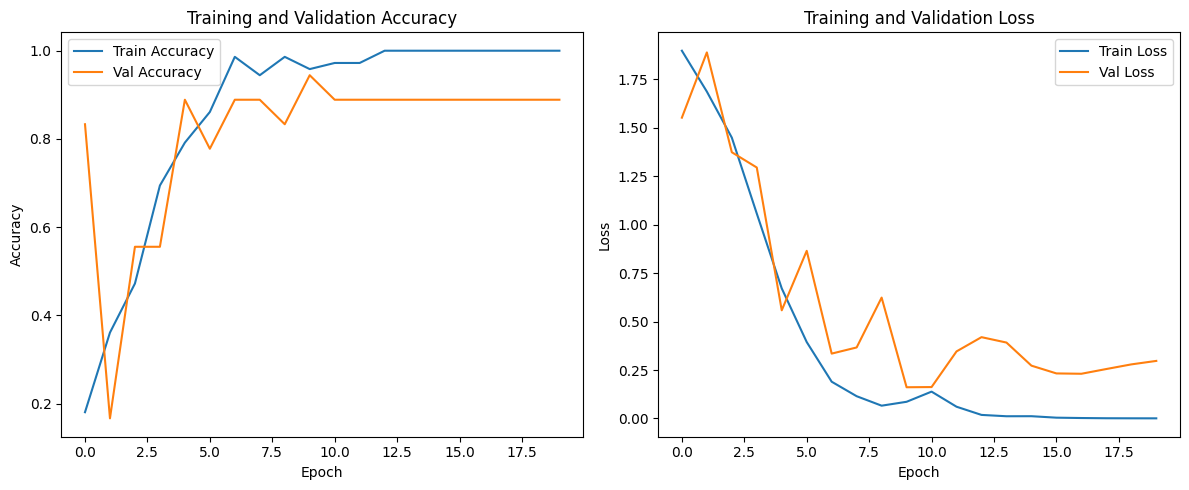

In [53]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Task 5: Evaluate on test set

In [54]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6667 - loss: 1.0962
Test Loss: 1.0961754322052002
Test Accuracy: 0.6666666865348816


# Task 6: Save and load the model

In [55]:
model.save("fruit_classifier_model.h5")
print("Model saved successfully.")

Model saved successfully.


In [56]:
loaded_model = keras.models.load_model("fruit_classifier_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.6667 - loss: 1.0962
Loaded Model Test Loss: 1.0961754322052002
Loaded Model Test Accuracy: 0.6666666865348816


# Task 7: Predictions and classification report

In [57]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.56      1.00      0.71         5
     guarana       0.80      0.80      0.80         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.50      0.20      0.29         5

    accuracy                           0.67        30
   macro avg       0.71      0.67      0.63        30
weighted avg       0.71      0.67      0.63        30

